# LFP extraction validation: LED driver ON at 0 ms

Short pipeline to check that LFP extraction and alignment are correct. We:
1. Define the sample block (PV_106, block 15) as in the saccade/LFP pipelines.
2. Parse OE events and collect **LED driver ON** (rising-edge) timestamps in ms.
3. Extract LFP windows ±50 ms around each LED ON, average, and plot with **LED event at 0 ms**.

If alignment is correct, you should see the expected LED-related artefacts (signal leak into EP) at 0 ms.

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from eye_tracking_system_tools.preprocessing import BlockSync
from eye_tracking_system_tools.preprocessing import utility_functions as uf

## Config

Same sample block as before. `lfp_channels` and `window_ms` match the saccade-LFP pipeline.

In [2]:
experiment_path = Path(r"D:\sample_data_for_eye_repo")
animal = "PV_106"
block_numbers = [15]
lfp_channels = [1]
window_ms = 100.0
half_window_ms = window_ms / 2

block_collection = uf.block_generator(
    block_numbers=block_numbers,
    experiment_path=experiment_path,
    animal=animal,
    bad_blocks=[],

)
block = block_collection[0]

# PV_106 channel mapping (same as block_sync)
block.channeldict = {
    1: "LED_driver",
    7: "L_eye_TTL",
    2: "Arena_TTL",
    8: "R_eye_TTL",
}

instantiated block number 015 at Path: D:\sample_data_for_eye_repo\PV_106\2025_09_04\block_015, new OE version
Found the sample rate for block 015 in the xml file, it is 20000 Hz

Extracting meta data from: D:\sample_data_for_eye_repo\PV_106\2025_09_04\block_015\oe_files\PV106_IMU_trial4_prey_2025-09-04_13-24-17\Record Node 106...
Analog channel numbers contain duplicates!!! Reordering numbers serially.

Extracting time stamp information...

Error!!! Some blocks are missing in recording!!!

Checking integrity of all records in ch1...

Metadata extraction complete.
created the .oe_rec attribute as an open ephys recording obj with get_data functionality (standalone mode, no metadata file)
retrieving zertoh sample number for block 015
got it!


## Parse OE events and collect LED driver ON (rising-edge) timestamps in ms

Run the same data-prep steps as block_sync (`handle_eye_videos`, `parse_open_ephys_events`, etc.) so `block.oe_events` exists. Extract `LED_driver` rising-edge sample numbers and convert to ms (`sample * 1000 / fs`).

In [3]:
block.handle_eye_videos()
block.parse_open_ephys_events()
block.handle_arena_files()
block.get_eye_brightness_vectors()

fs = block.sample_rate if hasattr(block, "sample_rate") else block.get_sample_rate()
if "LED_driver" not in (block.oe_events.columns if block.oe_events is not None else []):
    raise ValueError("LED_driver not in block.oe_events. Check channeldict and parsed events.")
led_on_samples = block.oe_events["LED_driver"].dropna().astype(np.int64).values
led_on_ms = led_on_samples * 1000.0 / fs
print(f"LED driver ON events: {len(led_on_ms)}; ms range [{led_on_ms.min():.1f}, {led_on_ms.max():.1f}]")

handling eye video files
converting videos...
converting files: ['D:\\sample_data_for_eye_repo\\PV_106\\2025_09_04\\block_015\\eye_videos\\LE\\imu_trial4_prey\\imu_trial4_prey.h264', 'D:\\sample_data_for_eye_repo\\PV_106\\2025_09_04\\block_015\\eye_videos\\RE\\imu_trial4_prey\\imu_trial4_prey.h264'] 
 avoiding conversion on files: ['D:\\sample_data_for_eye_repo\\PV_106\\2025_09_04\\block_015\\eye_videos\\LE\\imu_trial4_prey\\imu_trial4_prey_LE.mp4', 'D:\\sample_data_for_eye_repo\\PV_106\\2025_09_04\\block_015\\eye_videos\\RE\\imu_trial4_prey\\imu_trial4_prey.mp4']
The file D:\sample_data_for_eye_repo\PV_106\2025_09_04\block_015\eye_videos\RE\imu_trial4_prey\imu_trial4_prey.mp4 already exists, no conversion necessary
Validating videos...
The video named imu_trial4_prey_LE.mp4 has reported 19800 frames and has 19800 frames, it has dropped 0 frames
The video named imu_trial4_prey.mp4 has reported 19701 frames and has 19701 frames, it has dropped 0 frames
running parse_open_ephys_events...

## Extract LFP windows around each LED ON and average

Same ±50 ms window as saccade-LFP pipeline. Skip events outside `[0, recordingDuration_ms)`.

In [4]:
dur_ms = getattr(block.oe_rec, "recordingDuration_ms", None)
if dur_ms is not None and hasattr(dur_ms, "item"):
    dur_ms = float(dur_ms.item())
else:
    dur_ms = float(dur_ms) if dur_ms is not None else None

windows = []
for onset_ms in led_on_ms:
    start_ms = onset_ms - half_window_ms
    if dur_ms is not None and (start_ms < 0 or start_ms + window_ms > dur_ms):
        continue
    try:
        start_arr = np.atleast_2d(np.asarray([start_ms], dtype=float))
        data, _ = block.oe_rec.get_data(
            lfp_channels,
            start_arr,
            window_ms,
            convert_microvolts=True,
            return_timestamps=True,
            repress_output=True,
        )
    except Exception:
        continue
    if data is None or data.size == 0:
        continue
    win = data[0, 0, :]
    windows.append(win)

stack = np.stack(windows)
mean_lfp = np.nanmean(stack, axis=0)
n_samp = mean_lfp.size
t_rel_ms = np.linspace(-half_window_ms, half_window_ms, n_samp, endpoint=True)
diff_lfp = np.diff(mean_lfp)
t_diff_ms = (t_rel_ms[:-1] + t_rel_ms[1:]) / 2
print(f"Extracted {len(windows)} windows; mean trace length {n_samp}")

Extracted 7 windows; mean trace length 2000


## Plot averaged LFP and diff trace with LED ON at 0 ms

**Top:** averaged LFP (mV). **Bottom:** averaged diff (d/dt) — highlights sharp transients like LED artefact. Vertical line at 0 ms = LED driver ON.

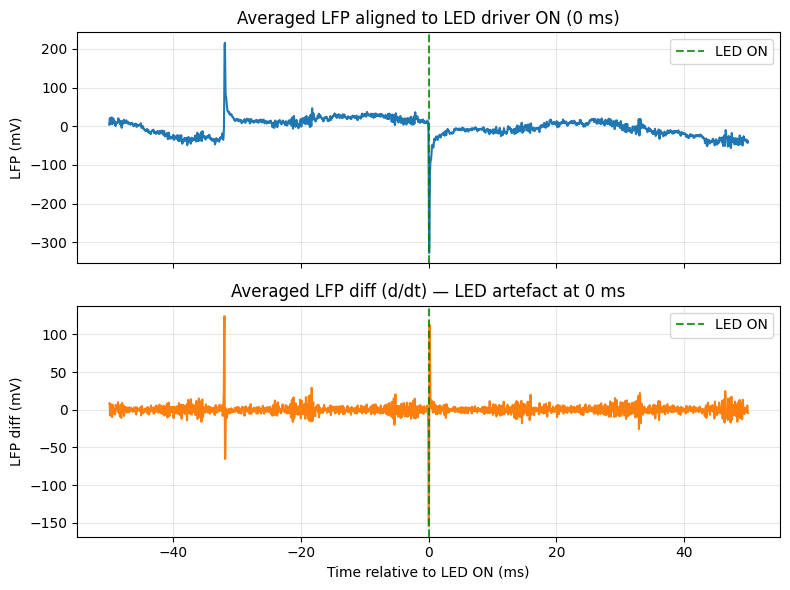

In [5]:
fig, (ax_raw, ax_diff) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax_raw.plot(t_rel_ms, mean_lfp, color="C0")
ax_raw.axvline(0, color="green", ls="--", alpha=0.8, label="LED ON")
ax_raw.set_ylabel("LFP (mV)")
ax_raw.set_title("Averaged LFP aligned to LED driver ON (0 ms)")
ax_raw.legend(loc="upper right")
ax_raw.grid(True, alpha=0.3)

ax_diff.plot(t_diff_ms, diff_lfp, color="C1")
ax_diff.axvline(0, color="green", ls="--", alpha=0.8, label="LED ON")
ax_diff.set_xlabel("Time relative to LED ON (ms)")
ax_diff.set_ylabel("LFP diff (mV)")
ax_diff.set_title("Averaged LFP diff (d/dt) — LED artefact at 0 ms")
ax_diff.legend(loc="upper right")
ax_diff.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()